In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/heart_2022_with_nans.csv")

df.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      445132 non-null  object 
 1   Sex                        445132 non-null  object 
 2   GeneralHealth              443934 non-null  object 
 3   PhysicalHealthDays         434205 non-null  float64
 4   MentalHealthDays           436065 non-null  float64
 5   LastCheckupTime            436824 non-null  object 
 6   PhysicalActivities         444039 non-null  object 
 7   SleepHours                 439679 non-null  float64
 8   RemovedTeeth               433772 non-null  object 
 9   HadHeartAttack             442067 non-null  object 
 10  HadAngina                  440727 non-null  object 
 11  HadStroke                  443575 non-null  object 
 12  HadAsthma                  443359 non-null  object 
 13  HadSkinCancer              44

In [ ]:
df.describe()

,PhysicalHealthDays,MentalHealthDays,SleepHours,HeightInMeters,WeightInKilograms,BMI
count,434205.000000,436065.000000,439679.000000,416480.000000,403054.000000,396326.000000
mean,4.347919,4.382649,7.022983,1.702691,83.074470,28.529842
std,8.688912,8.387475,1.502425,0.107177,21.448173,6.554889
min,0.000000,0.000000,1.000000,0.910000,22.680000,12.020000
25%,0.000000,0.000000,6.000000,1.630000,68.040000,24.130000
50%,0.000000,0.000000,7.000000,1.700000,80.740000,27.440000
75%,3.000000,5.000000,8.000000,1.780000,95.250000,31.750000
max,30.000000,30.000000,24.000000,2.410000,292.570000,99.640000


In [ ]:
df.shape

(445132, 40)

In [ ]:
df.columns

Index(['State', 'Sex', 'GeneralHealth', 'PhysicalHealthDays',
       'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities',
       'SleepHours', 'RemovedTeeth', 'HadHeartAttack', 'HadAngina',
       'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis',
       'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory',
       'HeightInMeters', 'WeightInKilograms', 'BMI', 'AlcoholDrinkers',
       'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap',
       'HighRiskLastYear', 'CovidPos'],
      dtype='object')

In [ ]:
df['HadHeartAttack'].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
df['HadHeartAttack'].value_counts()

,count
HadHeartAttack,
No,416959
Yes,25108


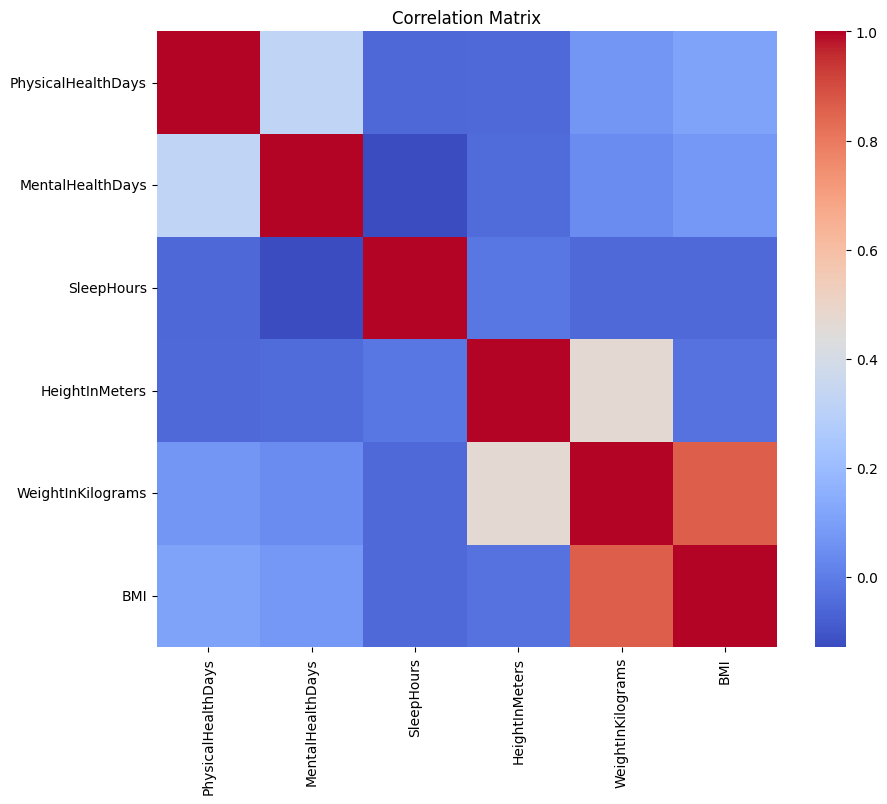

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

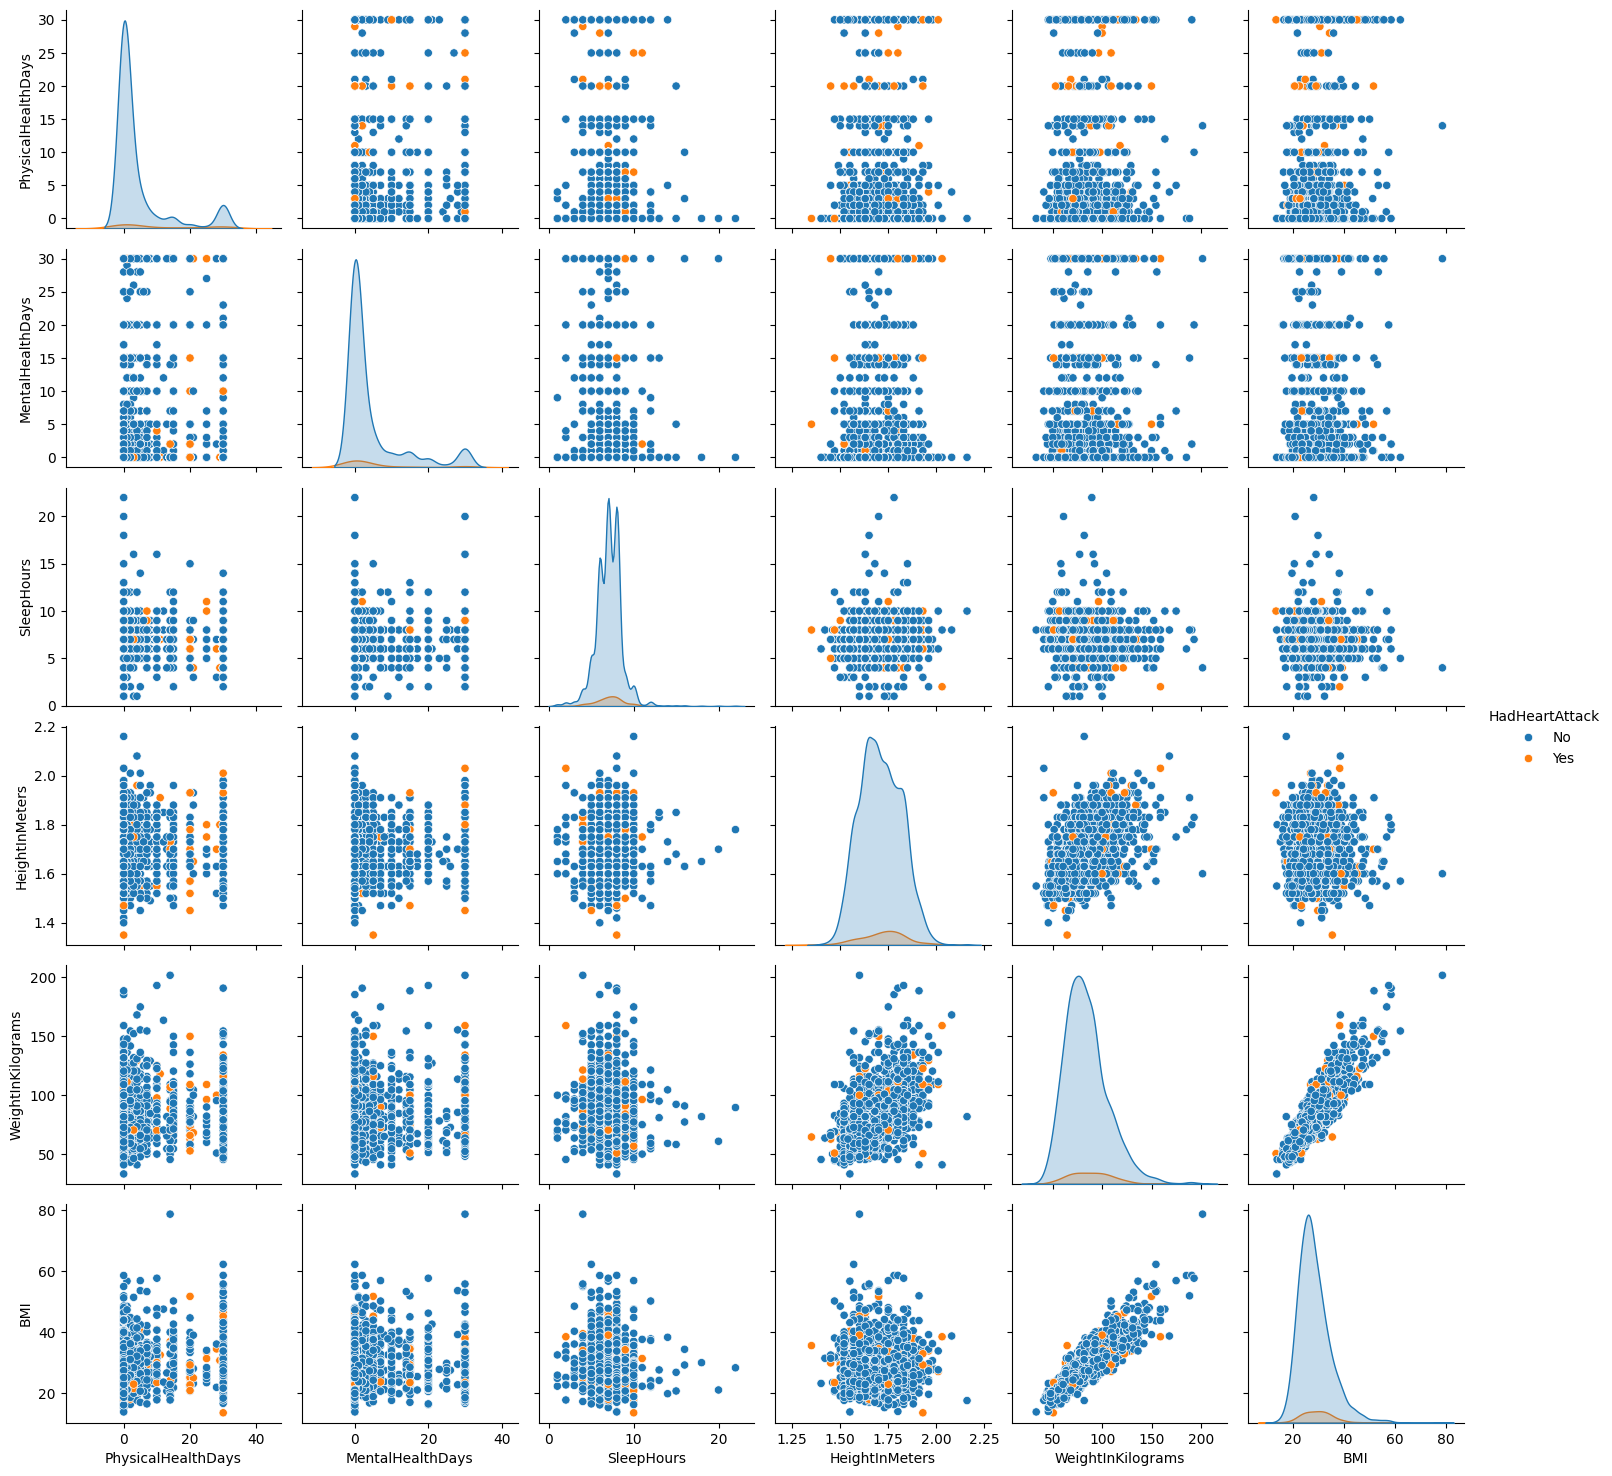

In [ ]:
sample_df = df.sample(2000)
sns.pairplot(sample_df, hue='HadHeartAttack')
plt.show()

In [ ]:
df['HadHeartAttack'] = df['HadHeartAttack'].str.strip()
df['HadHeartAttack'] = df['HadHeartAttack'].str.capitalize()

In [ ]:
df['HadHeartAttack'].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
df = df.dropna(subset=['HadHeartAttack']).reset_index(drop=True)

In [ ]:
df['HadHeartAttack'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df['HadHeartAttack'] = df['HadHeartAttack'].map({'No':0, 'Yes':1})

In [ ]:
df['HadHeartAttack'].unique()
df['HadHeartAttack'].value_counts()

,count
HadHeartAttack,
0,416959
1,25108


In [ ]:
df.shape

(442067, 40)

In [ ]:
columns_to_keep = [
    'HadHeartAttack',
    'AgeCategory',
    'Sex',
    'BMI',
    'GeneralHealth',
    'PhysicalHealthDays',
    'SleepHours',
    'SmokerStatus',
    'AlcoholDrinkers',
    'PhysicalActivities',
    'HadDiabetes',
    'HadKidneyDisease',
    'HadCOPD',
    'HadDepressiveDisorder',
    'DifficultyWalking'
]

df = df.drop(columns=[col for col in df.columns if col not in columns_to_keep])

In [ ]:
df.shape
df.columns

Index(['Sex', 'GeneralHealth', 'PhysicalHealthDays', 'PhysicalActivities',
       'SleepHours', 'HadHeartAttack', 'HadCOPD', 'HadDepressiveDisorder',
       'HadKidneyDisease', 'HadDiabetes', 'DifficultyWalking', 'SmokerStatus',
       'AgeCategory', 'BMI', 'AlcoholDrinkers'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Sex,0
GeneralHealth,1095
PhysicalHealthDays,10597
PhysicalActivities,972
SleepHours,5196
HadHeartAttack,0
HadCOPD,1838
HadDepressiveDisorder,2421
HadKidneyDisease,1614
HadDiabetes,813


In [ ]:
df.shape

(442067, 15)

In [ ]:
df.duplicated().sum()

np.int64(45719)

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(396348, 15)

In [ ]:
df = df[columns_to_keep]
print(df.shape)
X = df.drop('HadHeartAttack', axis=1)
y = df['HadHeartAttack']

(396348, 15)


In [ ]:
X.isnull().sum().sort_values(ascending=False)

,0
AlcoholDrinkers,35918
BMI,29516
SmokerStatus,25287
DifficultyWalking,14577
PhysicalHealthDays,10494
AgeCategory,6941
SleepHours,5075
HadDepressiveDisorder,2415
HadCOPD,1837
HadKidneyDisease,1612


In [ ]:
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [ ]:
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

In [ ]:
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

In [ ]:
X.isnull().sum().sum()

np.int64(0)

In [ ]:
X.isnull().sum()

,0
AgeCategory,0
Sex,0
BMI,0
GeneralHealth,0
PhysicalHealthDays,0
SleepHours,0
SmokerStatus,0
AlcoholDrinkers,0
PhysicalActivities,0
HadDiabetes,0


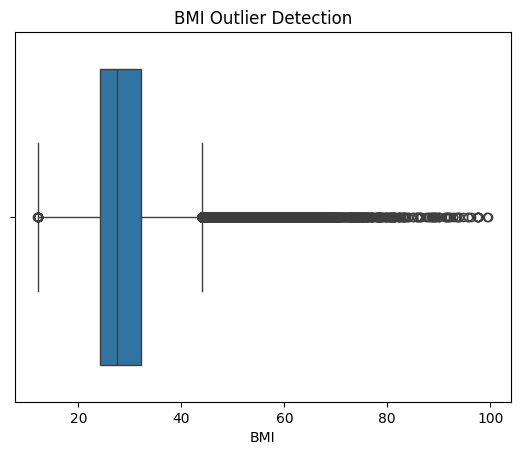

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['BMI'])
plt.title("BMI Outlier Detection")
plt.show()

In [ ]:
import numpy as np

Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['BMI'] = np.where(df['BMI'] > upper, upper,
                     np.where(df['BMI'] < lower, lower, df['BMI']))

In [ ]:
X['LifestyleRiskScore'] = (
    (X['SmokerStatus'] == 'Yes').astype(int) +
    (X['AlcoholDrinkers'] == 'Yes').astype(int) +
    (X['PhysicalActivities'] == 'No').astype(int)
)

In [ ]:
X = pd.get_dummies(X, drop_first=True)
import joblib
X = X.astype(int)
joblib.dump(X.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [ ]:
X.select_dtypes(include=['object']).columns

Index([], dtype='object')

In [ ]:
X = X.astype(int)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (317078, 33)
Test shape: (79270, 33)


In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("After SMOTE:", X_train_res.shape)

After SMOTE: (594172, 33)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.7560994070896935
ROC-AUC: 0.6093273317513132
              precision    recall  f1-score   support

           0       0.95      0.78      0.86     74272
           1       0.12      0.44      0.19      4998

    accuracy                           0.76     79270
   macro avg       0.54      0.61      0.52     79270
weighted avg       0.90      0.76      0.81     79270



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.8483158824271477
ROC-AUC: 0.5391974028948072
              precision    recall  f1-score   support

           0       0.94      0.89      0.92     74272
           1       0.10      0.19      0.13      4998

    accuracy                           0.85     79270
   macro avg       0.52      0.54      0.53     79270
weighted avg       0.89      0.85      0.87     79270



In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_res, y_train_res)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost
Accuracy: 0.7679071527690173
ROC-AUC: 0.6106831708340381
              precision    recall  f1-score   support

           0       0.95      0.79      0.86     74272
           1       0.12      0.43      0.19      4998

    accuracy                           0.77     79270
   macro avg       0.54      0.61      0.53     79270
weighted avg       0.90      0.77      0.82     79270



In [ ]:
models = {
    "Logistic": lr,
    "RandomForest": rf,
    "XGBoost": xgb
}

for name, model in models.items():
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Logistic
Accuracy: 0.7560994070896935
ROC-AUC: 0.6093273317513132
              precision    recall  f1-score   support

           0       0.95      0.78      0.86     74272
           1       0.12      0.44      0.19      4998

    accuracy                           0.76     79270
   macro avg       0.54      0.61      0.52     79270
weighted avg       0.90      0.76      0.81     79270


RandomForest
Accuracy: 0.8483158824271477
ROC-AUC: 0.5391974028948072
              precision    recall  f1-score   support

           0       0.94      0.89      0.92     74272
           1       0.10      0.19      0.13      4998

    accuracy                           0.85     79270
   macro avg       0.52      0.54      0.53     79270
weighted avg       0.89      0.85      0.87     79270


XGBoost
Accuracy: 0.7679071527690173
ROC-AUC: 0.6106831708340381
              precision    recall  f1-score   support

           0       0.95      0.79      0.86     74272
           1       0.12      0.43

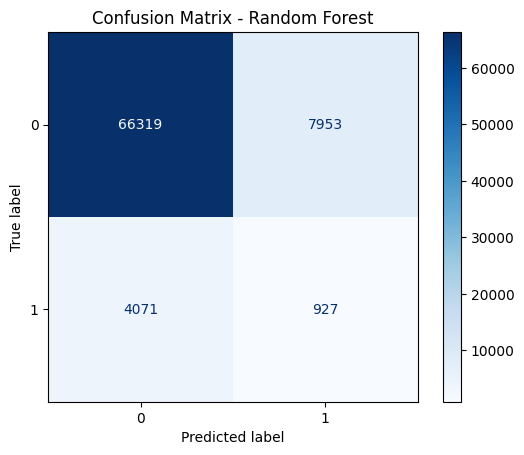

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

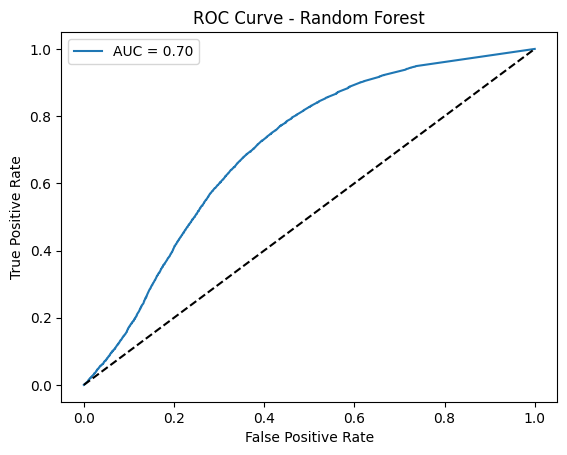

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob_rf = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
0,BMI,0.203316
2,SleepHours,0.102815
1,PhysicalHealthDays,0.087640
23,SmokerStatus_Never smoked,0.043665
20,GeneralHealth_Very good,0.040261
7,AgeCategory_Age 40 to 44,0.033646
6,AgeCategory_Age 35 to 39,0.032206
5,AgeCategory_Age 30 to 34,0.029529
8,AgeCategory_Age 45 to 49,0.028890
9,AgeCategory_Age 50 to 54,0.024669


In [ ]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "ROC_AUC": roc
    })

results_df = pd.DataFrame(results)

print(results_df)

          Model  Accuracy   ROC_AUC
0      Logistic  0.756099  0.609327
1  RandomForest  0.848316  0.539197
2       XGBoost  0.767907  0.610683


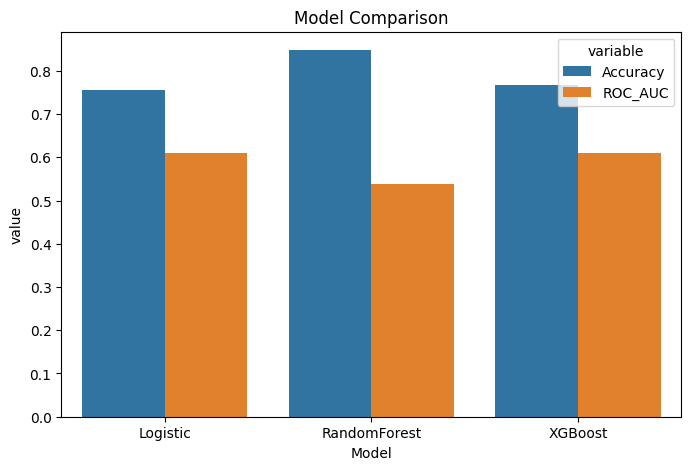

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

results_melt = results_df.melt(id_vars="Model")

plt.figure(figsize=(8,5))
sns.barplot(data=results_melt, x="Model", y="value", hue="variable")

plt.title("Model Comparison")
plt.show()

In [ ]:
import joblib

joblib.dump(rf, "heart_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
!ls

heart_2022_with_nans.csv  model_columns.pkl  scaler.pkl
heart_model.pkl		  sample_data


In [ ]:
from google.colab import files
files.download("model_columns.pkl")

files.download("heart_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>